# Generate Plots of Absolute Geostrophic Velocity in transects of the Beaufort Gyre

### Configure the notebook and load necessary packages

In [1]:
#Jupyter Notebook config
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
#Load necessary python packages
import matplotlib.pyplot as plt
from matplotlib import colormaps
import cartopy.crs as ccrs
from cmocean import cm
import numpy as np

#Import custom package for working with Beaufort Gyre data
from datatools import io
import datatools.ctd.operations as dsops
import datatools.plots.maps as mapper
import datatools.plots.section as plotter
import ocean_tools as fod
from datatools.DOT.DataServer import DataServer

### Extract the CTD Transects from the full dataset
* Read in the data
* Extract each transect
* Plot the transects on a map

In [3]:
#Read raw CTD data
ds = io.readers.readLSSL("/Users/ben/Desktop/3D-TEA-BAG/data/BG_LSSL_CTD_2003-2025.nc")

#Slice the data to extract each transect
#Eastern N-S transect (IVO 140˚W)
e_ns_transect = dsops.var_slice(ds, 'lon', -140.5, -139.5)
#ADD OTHER THREE TRANSECTS

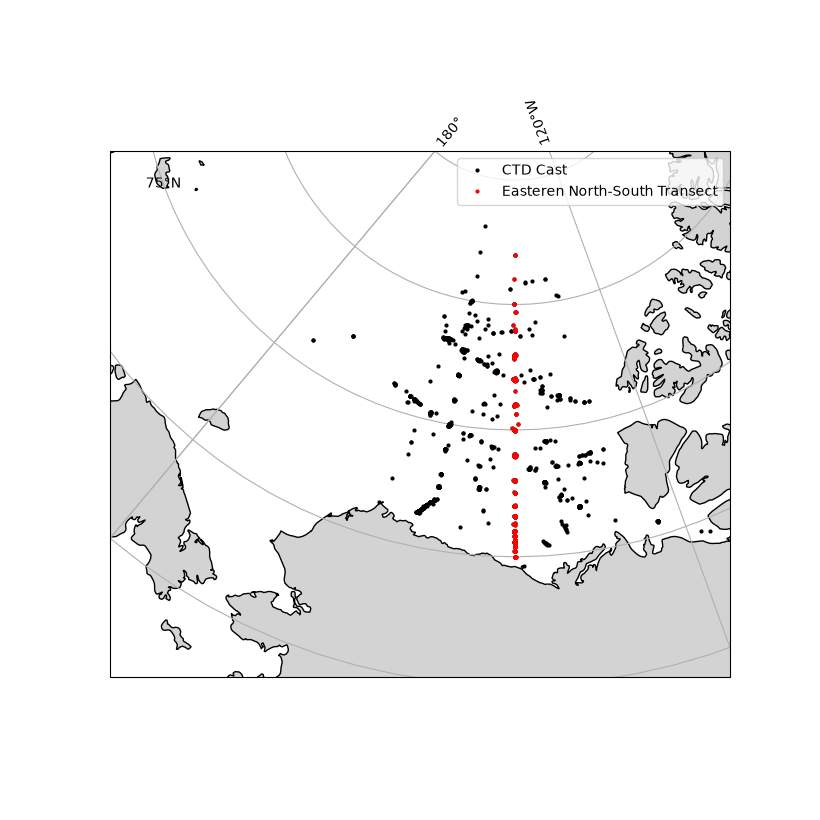

In [4]:
#Plot the transects

#Setup the basemap
transect_location_figure = plt.figure(figsize=(8,8))
projection=ccrs.NorthPolarStereo(central_longitude=-140)
extent = [-180, -120, 65, 85]

ax = mapper.setup_map(figure=transect_location_figure,
                 projection=projection,
                 extent=extent)

#Plot all casts
ax = mapper.plot_station_locations(ax = ax, ds = ds, label = 'CTD Cast')

#Plat the transects
ax = mapper.plot_station_locations(ax = ax, ds = e_ns_transect, color='r', label = 'Easteren North-South Transect')

#Finish the plot off
plt.title("Beaufort Gyre Exploration Project Shipboard CTD Cast Locations") #WHY DOESNT THIS WORK?
plt.legend()

plt.show()

### Preprocess the CTD Transects
* Split each transect dataset into an array of data arrays (one for each cruise year)
* Run the injest/cleaning function on each array of transects to remove nan data, calculate various parameters, ensure all variable naming is consistent, and add variable metadata to easier plotting later on
* Includes calculature thermal wind shear ($\frac{\partial \vec{V_g}}{\partial z} = \frac{g}{\rho f_c}(\nabla \times \rho)$)

In [5]:
#Split data into a dataset per cruise 
e_ns_cruise_transects = dsops.split_by_coordinate(e_ns_transect, 'cruise')
#Clean each dataset
for key in e_ns_cruise_transects:
    #Clean and injest the transect data (add many new and useful variables)
    e_ns_cruise_transects[key] = dsops.injest_CTD_transect(e_ns_cruise_transects[key], datum=(70,-140))

### Calculate Absolute Geostrophic Velocity
$\vec{V_g} = \int_{z_0}^{z} \frac{\partial \vec{V_g}}{\partial z} \,dz + \vec{V}_{g, z_0}$
1. Calculate based on a level of no motion of 1000m
2. Calculate based on satelite derived surface geostrophic current


#### Level of no motion at 1000m

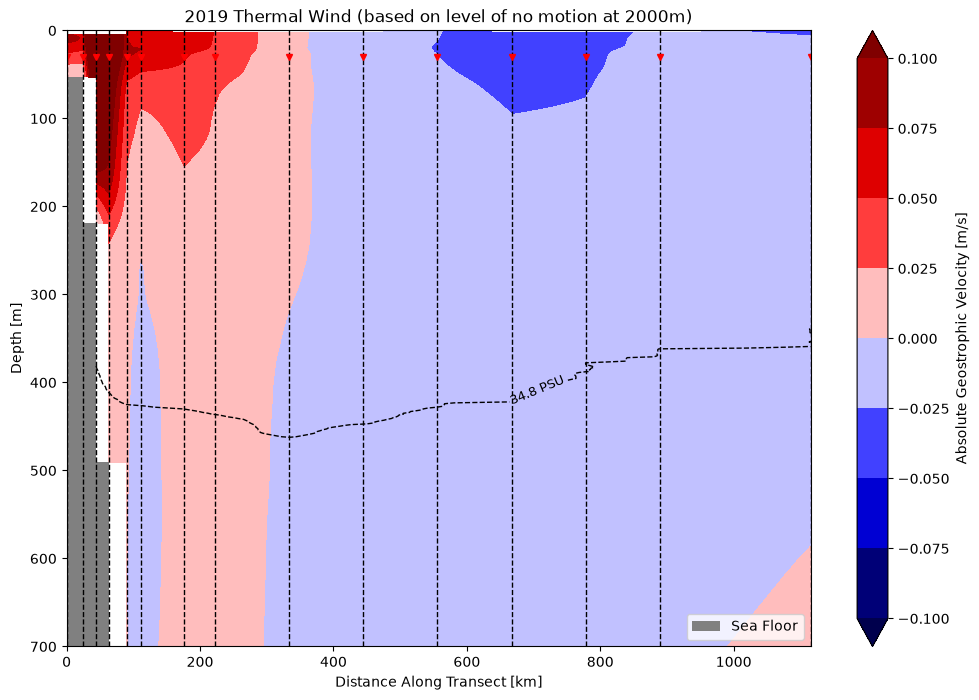

In [20]:
year = 2019
transect = e_ns_cruise_transects[year]
level_no_motion = 2000

abs_geo_vel = dsops.integrate_from_level_of_no_motion(transect, level_no_motion)

transect['asv_lom_1000'] = abs_geo_vel



field_figure = plt.figure(figsize=(12,8))
ax = field_figure.add_subplot(1,1,1) 

field_figure, ax = plotter.plot_transect(
    transect=transect,
    x = 'distance',
    y = 'depth',
    data = 'asv_lom_1000',
    fig = field_figure,
    ax = ax,
    cmap = colormaps['seismic'],
    title = f'{year} Thermal Wind (based on level of no motion at {level_no_motion}m)',
    levels = 0.1
    )

plt.show()

In [7]:
sat_data = DataServer("/Users/ben/Desktop/3D-TEA-BAG/data/CPOM_DOT.nc", "/Users/ben/Desktop/3D-TEA-BAG/data/Full_DOT_data_Arco_2025_09.nc")

/Users/ben/Desktop/3D-TEA-BAG/datatools/ctd/operations.py:41: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  - pden


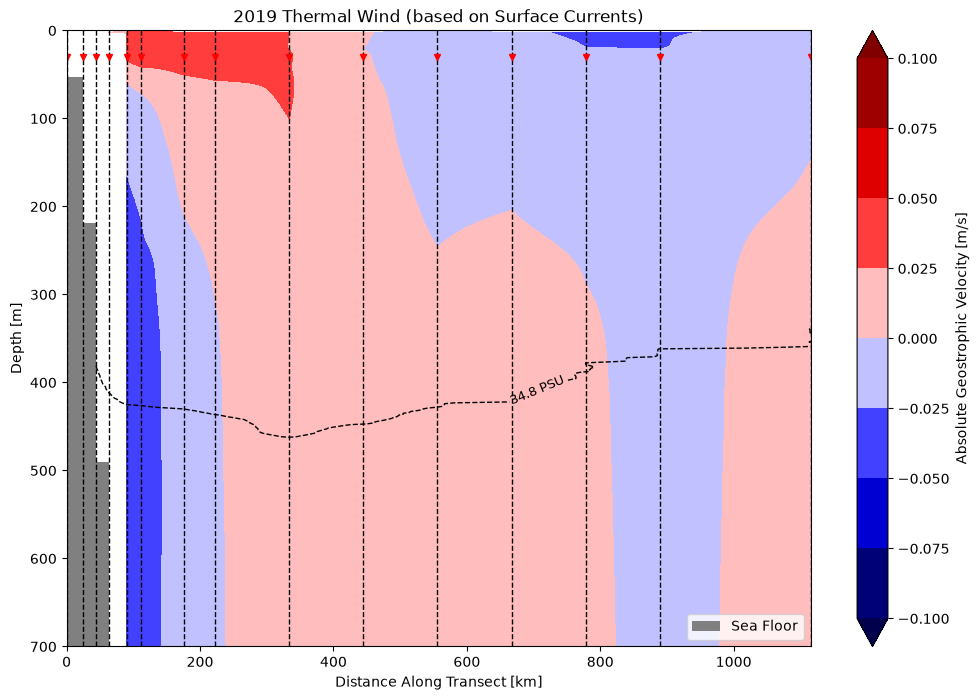

In [17]:
transect = e_ns_cruise_transects[year]

abs_geo_vel = dsops.integrate_from_surface_current(transect, sat_data, 'ns')

transect['asv_surf_current'] = abs_geo_vel



field_figure = plt.figure(figsize=(12,8))
ax = field_figure.add_subplot(1,1,1) 

field_figure, ax = plotter.plot_transect(
    transect=transect,
    x = 'distance',
    y = 'depth',
    data = 'asv_surf_current',
    fig = field_figure,
    ax = ax,
    cmap = colormaps['seismic'],
    title = f'{year} Thermal Wind (based on Surface Currents)',
    levels = 0.1
    )

plt.show()